# Import Library

In [1]:
import numpy as np
import matplotlib as plt
import seaborn as sns
import requests
import pandas as pd
from bs4 import BeautifulSoup
import openpyxl

# Scrapping Website CoinMarketCap

In [2]:
import numpy as np
import matplotlib.pyplot as plt  
import seaborn as sns
import requests
import pandas as pd
from bs4 import BeautifulSoup


def scrape():
    url = 'https://coinmarketcap.com/gainers-losers/'
    headers = {
        'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) ...'
    }
    try:
        response = requests.get(url, headers=headers)
    except Exception as e:
        print(f"Koneksi gagal: {e}")
        return [], []

    if response.status_code != 200:
        print(f'Error: {response.status_code}')
        return [], []

    soup = BeautifulSoup(response.text, 'html.parser')
    tables = soup.findAll('table', class_='cmc-table')

    if len(tables) < 2:
        print("Tabel tidak ditemukan (kemungkinan konten di-render oleh JS).")
        return [], []

    def parse_table(target_table):
        data = []
        rows = target_table.findAll('tr')[1:]
        for row in rows:
            cols = row.findAll('td')
            if len(cols) >= 5:  # ✅ minimal 5 kolom
                data.append({
                    "Name": cols[1].text.strip(),
                    "Price": cols[2].text.strip(),
                    "24h Change": cols[3].text.strip(),
                    "Volume(24h)": cols[4].text.strip()
                })
        return data

    return parse_table(tables[0]), parse_table(tables[1])

gainers, losers = scrape()

if gainers or losers:
    df_gainers = pd.DataFrame(gainers)
    df_gainers.to_excel("gainers.xlsx", index=False)  # ✅ index=False

    df_losers = pd.DataFrame(losers)
    df_losers.to_excel("losers.xlsx", index=False)

C:\Users\Asus\AppData\Local\Temp\ipykernel_18012\2900036570.py:25: DeprecationWarning: Call to deprecated method findAll. (Replaced by find_all) -- Deprecated since version 4.0.0.
  tables = soup.findAll('table', class_='cmc-table')
C:\Users\Asus\AppData\Local\Temp\ipykernel_18012\2900036570.py:33: DeprecationWarning: Call to deprecated method findAll. (Replaced by find_all) -- Deprecated since version 4.0.0.
  rows = target_table.findAll('tr')[1:]
C:\Users\Asus\AppData\Local\Temp\ipykernel_18012\2900036570.py:35: DeprecationWarning: Call to deprecated method findAll. (Replaced by find_all) -- Deprecated since version 4.0.0.
  cols = row.findAll('td')


# DataFrame Gainners Coin

In [3]:
gainners = pd.read_excel("gainers.xlsx")
dataframe_gainners = pd.DataFrame(gainners)
dataframe_gainners.head(10)

,Name,Price,24h Change,Volume(24h)
0,RaveDAO89RAVE,$2.09,259.37%,"$583,479,523"
1,币安人生86币安人生,$0.4712,16.54%,"$101,851,514"
2,Pudgy Penguins84PENGU,$0.007551,6.38%,"$130,796,596"
3,Chiliz83CHZ,$0.04611,5.26%,"$186,473,288"
4,Toncoin29TON,$1.36,4.19%,"$168,158,164"
5,Venice Token91VVV,$9.38,4.10%,"$18,963,374"
6,Canton16CC,$0.1568,4.01%,"$20,902,642"
7,MemeCore21M,$3.37,3.80%,"$24,938,158"
8,Monad98MON,$0.03113,3.54%,"$80,591,812"
9,Stellar17XLM,$0.1743,3.46%,"$123,974,176"


# DataFrame Lossers Coin

In [4]:
loserss = pd.read_excel("losers.xlsx")
dataframe_losers = pd.DataFrame(loserss)
dataframe_losers.head(10)

,Name,Price,24h Change,Volume(24h)
0,Ethena56ENA,$0.111,4.05%,"$105,208,608"
1,DeXe52DEXE,$14.33,1.42%,"$34,444,895"
2,Morpho64MORPHO,$1.90,1.41%,"$14,061,153"
3,ether.fi97ETHFI,$0.4533,1.15%,"$26,036,870"
4,TRON8TRX,$0.3288,1.13%,"$779,915,266"
5,Pi42PI,$0.1702,1.08%,"$21,329,138"
6,Midnight73NIGHT,$0.0362,1.05%,"$21,716,077"
7,Jupiter74JUP,$0.1682,1.03%,"$21,067,390"
8,Uniswap38UNI,$3.24,0.97%,"$222,471,669"
9,siren80SIREN,$0.714,0.91%,"$17,078,832"


# Check Missing Value Gainners

In [5]:
df_gainers.isnull().sum()

Name           0
Price          0
24h Change     0
Volume(24h)    0
dtype: int64

# Check Missing Value Lossers

In [6]:
df_losers.isnull().sum()

Name           0
Price          0
24h Change     0
Volume(24h)    0
dtype: int64

# Data Cleaning Gainners & Lossers

In [7]:
for df in [df_gainers, df_losers]:
    df['Price'] = df['Price'].str.replace('$', '', regex=False).str.replace(',', '').astype(float)
    df['24h Change'] = df['24h Change'].str.replace('%', '', regex=False).astype(float)
    df['Volume(24h)'] = df['Volume(24h)'].str.replace('$', '', regex=False).str.replace(',', '').astype(float)

df_gainers.head()

,Name,Price,24h Change,Volume(24h)
0,RaveDAO89RAVE,2.090000,259.37,583479523.0
1,币安人生86币安人生,0.471200,16.54,101851514.0
2,Pudgy Penguins84PENGU,0.007551,6.38,130796596.0
3,Chiliz83CHZ,0.046110,5.26,186473288.0
4,Toncoin29TON,1.360000,4.19,168158164.0


# Check Outlier Gainners

In [8]:
Q1 = df_gainers['Price'].quantile(0.25)
Q3 = df_gainers['Price'].quantile(0.75)
IQR = Q3 - Q1  

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outlier_iqr = df_gainers[
    (df_gainers['Price'] < lower) | (df_gainers['Price'] > upper)
]

print('Jumlah outlier dari gainers: ', len(outlier_iqr))

Jumlah outlier dari gainers:  6


# Check Outlier Lossers

In [9]:
Q1 = df_losers['Price'].quantile(0.25)
Q3 = df_losers['Price'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

qutlier_iqr = df_losers[
    (df_losers['Price'] < lower) | (df_losers['Price'] > upper)
]

print('Jumlah outlier dari losers: ', len(qutlier_iqr))

Jumlah outlier dari losers:  2


# Handling Outlier Gainners

In [10]:
data_iqr_clean_gainners = df_gainers[
    (df_gainers['Price'] >= lower) & (df_gainers['Price'] <= upper)
]

print("Jumlah data yang bersih: ", len(data_iqr_clean_gainners))

Jumlah data yang bersih:  23


# EDA Gainners

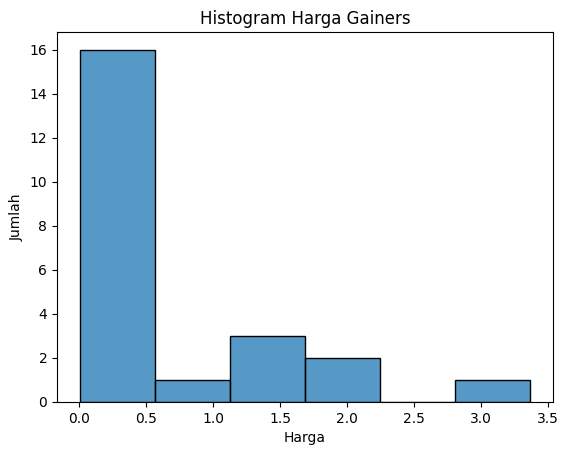

In [11]:
import matplotlib.pyplot as plt
sns.histplot(data=data_iqr_clean_gainners[data_iqr_clean_gainners['Price'] <  20000], x='Price')
plt.xlabel('Harga')
plt.ylabel('Jumlah')
plt.title('Histogram Harga Gainers')
plt.show()

# Handling Outlier Lossers

In [12]:
data_iqr_clean_lossers = df_losers[
    (df_losers['Price'] >= lower) & (df_losers['Price'] <= upper)
]

print("Jumlah data yang bersih: ", len(data_iqr_clean_lossers))

Jumlah data yang bersih:  13


# EDA lossers

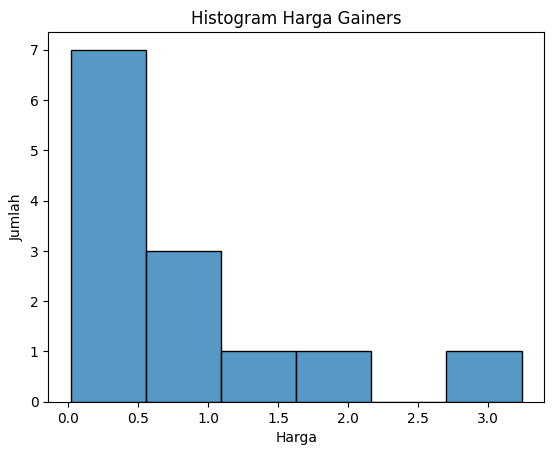

In [13]:
import matplotlib.pyplot as plt
sns.histplot(data=data_iqr_clean_lossers[data_iqr_clean_lossers['Price'] <  20000], x='Price')
plt.xlabel('Harga')
plt.ylabel('Jumlah')
plt.title('Histogram Harga Gainers')
plt.show()

# EDA Pie Chart (Perubahan Koin Gainners dalam 24 jam terakhir)

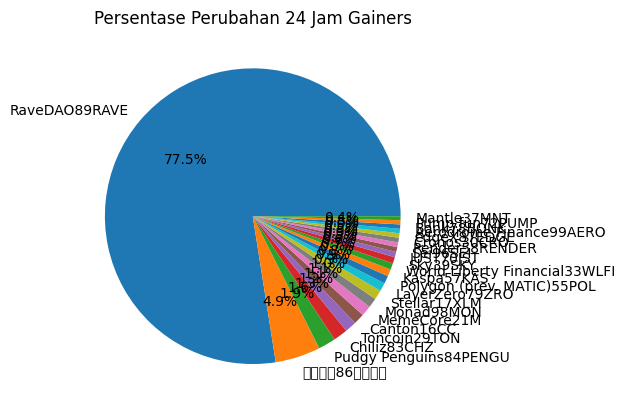

In [15]:
plt.Figure(figsize=(10, 6))
plt.pie(data_iqr_clean_gainners['24h Change'], labels=data_iqr_clean_gainners['Name'], autopct='%1.1f%%')
plt.title('Persentase Perubahan 24 Jam Gainers')
plt.show()

# EDA Pie Chart (Perubahan Koin Lossers dalam 24 jam terakhir)

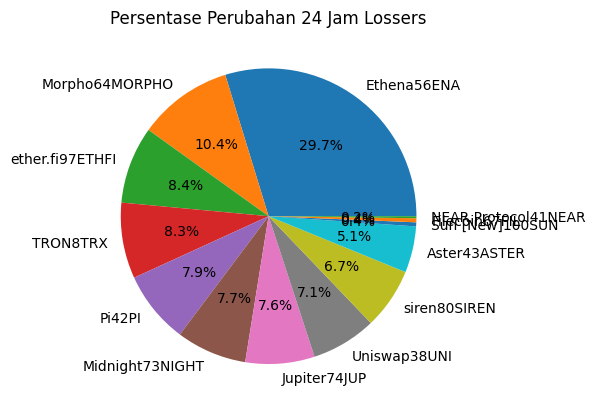

In [16]:
plt.Figure(figsize=(10, 6))
plt.pie(data_iqr_clean_lossers['24h Change'], labels=data_iqr_clean_lossers['Name'], autopct='%1.1f%%')
plt.title('Persentase Perubahan 24 Jam Lossers')
plt.show()